# reading files and getting ave sampling rate

In [815]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

''' csv file keys: 
'time', 'seconds_elapsed', 'rotationRateX', 'rotationRateY',
'rotationRateZ', 'gravityX', 'gravityY', 'gravityZ', 'accelerationX',
'accelerationY', 'accelerationZ', 'quaternionW', 'quaternionX',
'quaternionY', 'quaternionZ', 'pitch', 'roll', 'yaw'

Sensor logger sampling rate is 100 Hz
'''

# Reading in file
# path_to_file = "/Volumes/disko!/HomeStretch/001_BicepCurl_R_T.csv" # update this to the path of your file
# path_to_file = "/Volumes/disko!/HomeStretch/002_BicepCurl_R_A.csv"

path_to_file = r"C:\Users\ahasa\Downloads\002_BicepCurl_R_A.csv" # update this to the path of your file
# path_to_file = r"C:\Users\Jade Chng\Desktop\HomeStretchRepo\Atypical\002_BicepCurl_R_A.csv"

df = pd.read_csv(path_to_file)

# getting sampling rate from the data
time = df['seconds_elapsed'].values
dt = np.diff(time)
sampling_rate = 1 / np.mean(dt)
print(f"Estimated Sampling Rate: {sampling_rate:.2f} Hz")

Estimated Sampling Rate: 99.69 Hz


# plotting inital plots

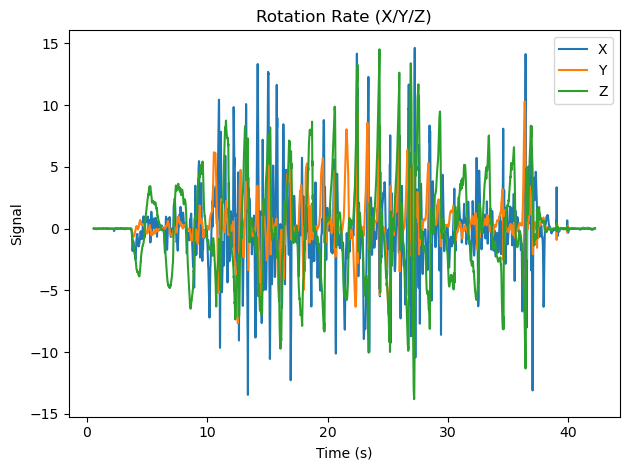

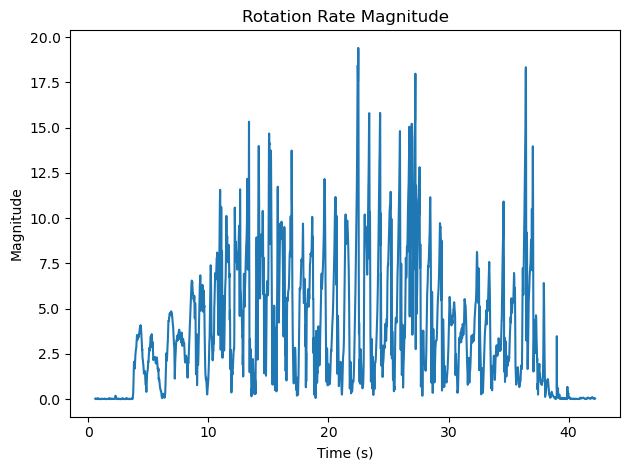

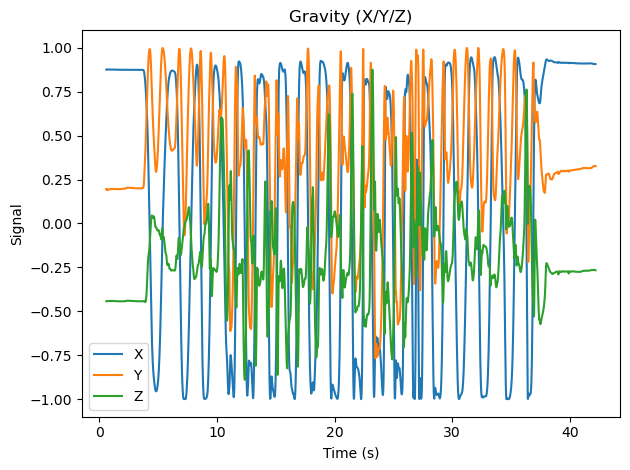

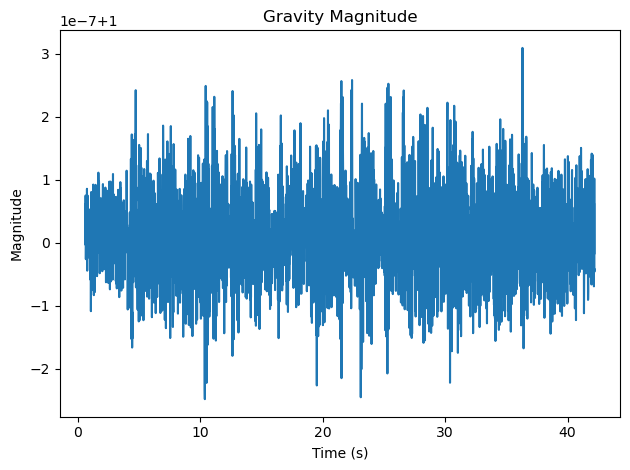

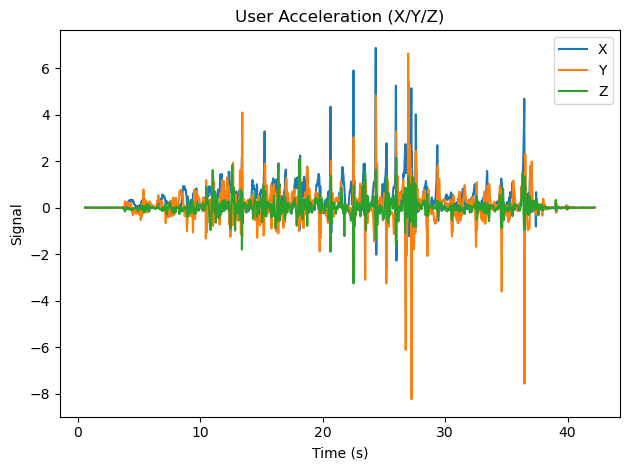

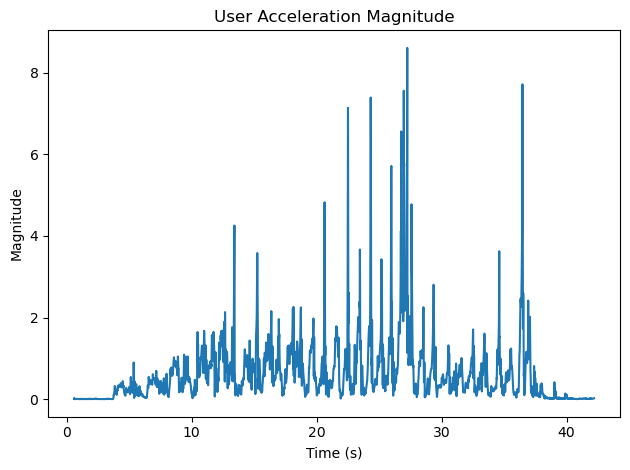

In [817]:
# ---- Helper: plot 3-axis + magnitude ----
def plot_3axis_and_mag(df, t_col, x_col, y_col, z_col, title_prefix):
    t = df[t_col].values
    x = df[x_col].values
    y = df[y_col].values
    z = df[z_col].values
    mag = np.sqrt(x**2 + y**2 + z**2)

    # 3-axis plot
    plt.figure()
    plt.plot(t, x, label='X')
    plt.plot(t, y, label='Y')
    plt.plot(t, z, label='Z')
    plt.xlabel("Time (s)")
    plt.ylabel("Signal")
    plt.title(f"{title_prefix} (X/Y/Z)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # magnitude plot
    plt.figure()
    plt.plot(t, mag)
    plt.xlabel("Time (s)")
    plt.ylabel("Magnitude")
    plt.title(f"{title_prefix} Magnitude")
    plt.tight_layout()
    plt.show()

# ---- Plot rotation rate ----
plot_3axis_and_mag(
    df, 'seconds_elapsed',
    'rotationRateX', 'rotationRateY', 'rotationRateZ',
    "Rotation Rate"
)

# ---- Plot gravity ----
plot_3axis_and_mag(
    df, 'seconds_elapsed',
    'gravityX', 'gravityY', 'gravityZ',
    "Gravity"
)

# ---- Plot acceleration ----
plot_3axis_and_mag(
    df, 'seconds_elapsed',
    'accelerationX', 'accelerationY', 'accelerationZ',
    "User Acceleration"
)


# manually segment start and end of excersize

Segment shape: (3908, 18)
Segment time range: 3.006744146347046 to 42.19718050956726


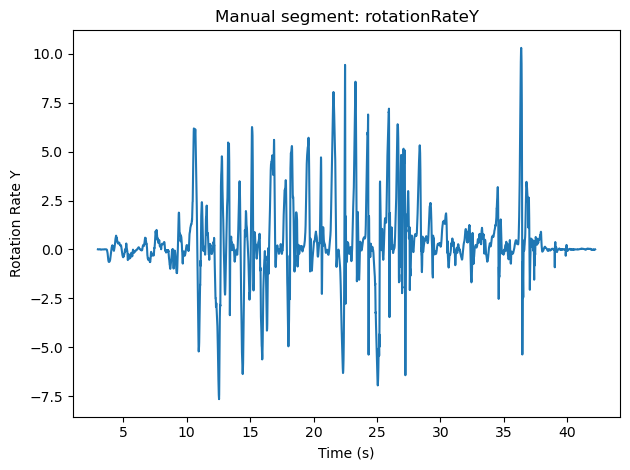

In [819]:
# 1) Choose manual boundaries (edit these)
start_time = 3.0
end_time   = 48.0

# start_time = 0.0
# end_time   = 41.0

# 2) Slice
df_seg = df[(df['seconds_elapsed'] >= start_time) &
            (df['seconds_elapsed'] <= end_time)].copy()

print("Segment shape:", df_seg.shape)
print("Segment time range:",
      df_seg['seconds_elapsed'].iloc[0], "to", df_seg['seconds_elapsed'].iloc[-1])

# 3) Replot to confirm (pick the clean axis you liked)
t_seg = df_seg['seconds_elapsed'].values
sig_seg = df_seg['rotationRateY'].values

plt.figure()
plt.plot(t_seg, sig_seg)
plt.title("Manual segment: rotationRateY")
plt.xlabel("Time (s)")
plt.ylabel("Rotation Rate Y")
plt.tight_layout()
plt.show()

df = df_seg # update df to be the segmented version for the rest of the analysis


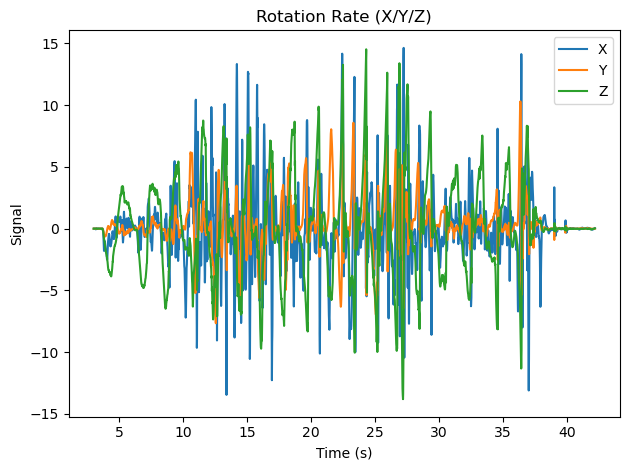

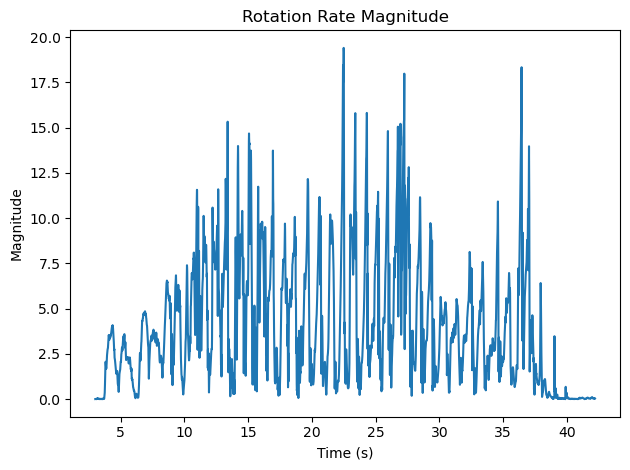

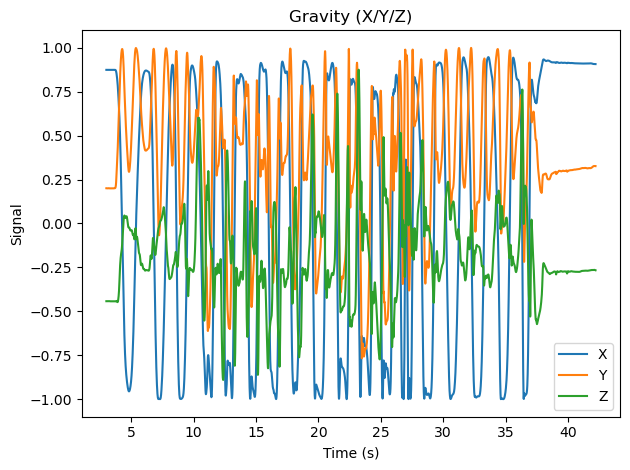

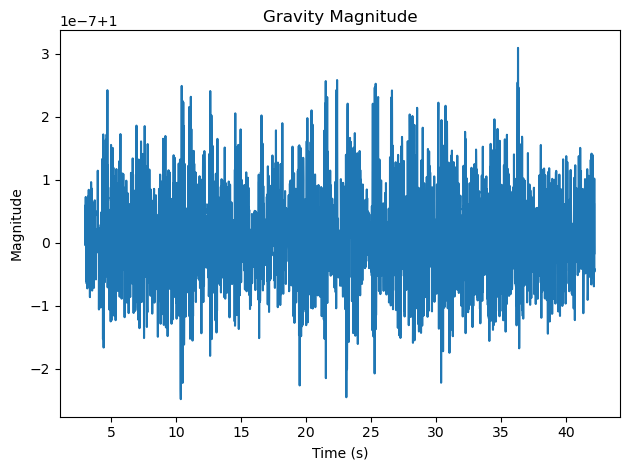

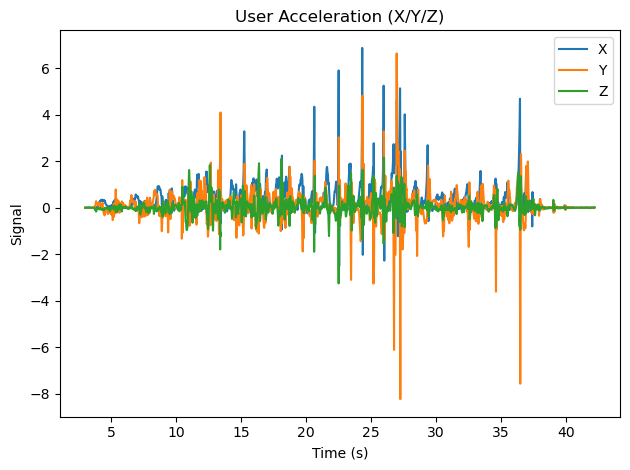

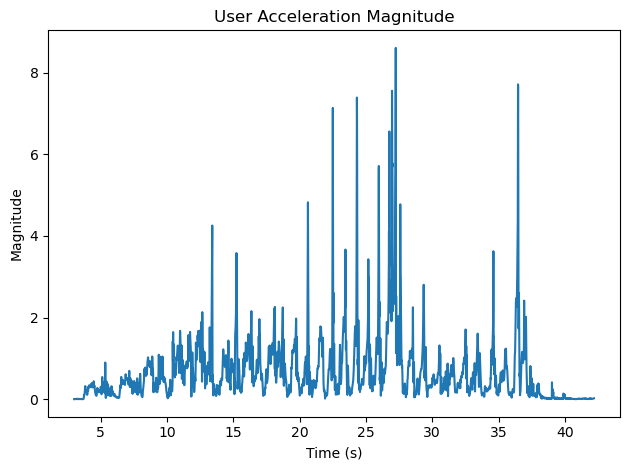

In [820]:
plot_3axis_and_mag(
    df, 'seconds_elapsed',
    'rotationRateX', 'rotationRateY', 'rotationRateZ',
    "Rotation Rate"
)

# ---- Plot gravity ----
plot_3axis_and_mag(
    df, 'seconds_elapsed',
    'gravityX', 'gravityY', 'gravityZ',
    "Gravity"
)

# ---- Plot acceleration ----
plot_3axis_and_mag(
    df, 'seconds_elapsed',
    'accelerationX', 'accelerationY', 'accelerationZ',
    "User Acceleration"
)

# Preprocessing 

## Bias Removal & Low-Pass

In [823]:
from scipy.signal import butter, filtfilt


Fs = sampling_rate  # from earlier estimate
def highpass(x, Fs, cutoff_hz, order=2):
    nyq = 0.5 * Fs
    b, a = butter(order, cutoff_hz / nyq, btype='high')
    return filtfilt(b, a, x)

def lowpass(x, Fs, cutoff_hz, order=2):
    nyq = 0.5 * Fs
    b, a = butter(order, cutoff_hz / nyq, btype='low')
    return filtfilt(b, a, x)

sig = df_seg['gravityX'].values
sig_filtered = lowpass(sig, Fs, 1, order=2)  # low-pass
sig_filtered = highpass(sig_filtered, Fs, cutoff_hz=0.3, order=2) # bias removal 

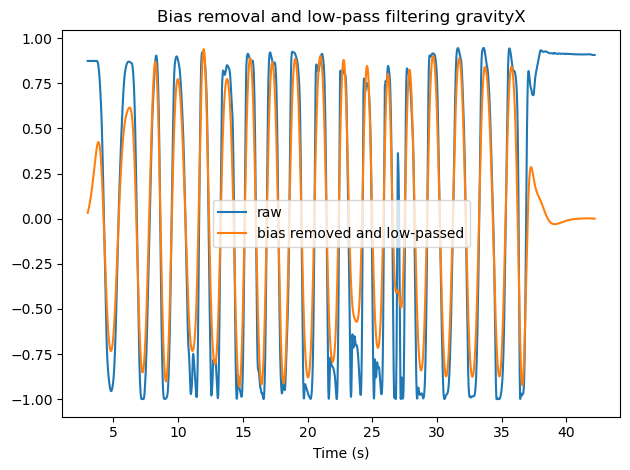

In [824]:
t = df_seg['seconds_elapsed'].values
sig = df_seg['gravityX'].values

plt.figure()
plt.plot(t, sig, label='raw')
plt.plot(t, sig_filtered, label='bias removed and low-passed')
plt.legend()
plt.title("Bias removal and low-pass filtering gravityX")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [825]:
print("Raw mean:", np.mean(sig))
print("HP mean:", np.mean(sig_filtered))

Raw mean: 0.09018825384305157
HP mean: 0.0012846994101202267


In [826]:
def detect_exercise_bounds(signal, time, Fs, rms_window_sec=0.5, threshold_ratio=0.2):
    
    # --- Filter signal same way as rep detection ---
    signal = lowpass(signal, Fs, 1, order=2)
    signal = highpass(signal, Fs, cutoff_hz=0.1, order=2)

    # --- Compute sliding RMS ---
    window_samples = int(rms_window_sec * Fs)
    squared = signal**2
    rms = np.sqrt(np.convolve(squared, 
                              np.ones(window_samples)/window_samples, 
                              mode='same'))

    # --- Threshold ---
    threshold = threshold_ratio * np.max(rms)
    active = rms > threshold

    # --- Find first and last active samples ---
    active_indices = np.where(active)[0]

    if len(active_indices) == 0:
        return None, None

    start_idx = active_indices[0]
    end_idx   = active_indices[-1]

    start_time = time[start_idx]
    end_time   = time[end_idx]

    return start_time, end_time

# segment by peaks

In [828]:
from scipy.signal import find_peaks

t = df['seconds_elapsed'].values
sig = df['gravityX'].values

def segment_rep(signal,time):

    # conduct low-pass filter and bias removal 
    signal = lowpass(signal, Fs, 1, order=2)  # low-pass
    signal = highpass(signal, Fs, cutoff_hz=0.1, order=2) # bias removal 
    
    # finding peaks 
    peaks, properties = find_peaks(signal, prominence=0.05, distance=20)

    rep_times = []
    
    # Each rep = between consecutive peaks
    for i in range(len(peaks) - 1):
        start_time = time[peaks[i]]
        end_time = time[peaks[i+1]]
        rep_times.append((start_time, end_time))
    
    n_reps = len(rep_times)
    
    return rep_times, n_reps

    return peaks, properties
rep_times, n_reps = segment_rep(sig,t)
print(n_reps)

exercise_start, exercise_end = detect_exercise_bounds(sig, t, Fs)

print("Exercise start:", exercise_start)
print("Exercise end:", exercise_end)

18
Exercise start: 3.006744146347046
Exercise end: 38.41556787490845


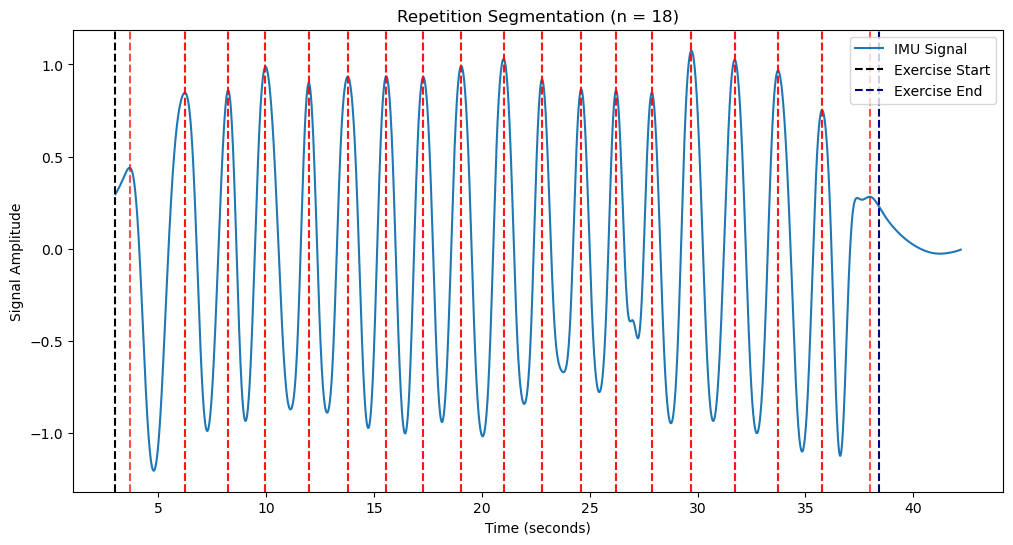

In [829]:
def plot_reps(signal, time, rep_times, exercise_start=None, exercise_end=None):
    
    plt.figure(figsize=(12,6))
    plt.plot(time, signal, label='IMU Signal')
    
    for i, (start, end) in enumerate(rep_times):
        plt.axvline(start, color='red',linestyle='--', alpha=0.7)
        plt.axvline(end, color='red', linestyle='--', alpha=0.7)

    if exercise_start is not None:
        plt.axvline(exercise_start, color='black', linestyle='--', label='Exercise Start')
        
    if exercise_end is not None:
        plt.axvline(exercise_end, color='navy', linestyle='--', label='Exercise End')
    
    plt.xlabel('Time (seconds)')
    plt.ylabel('Signal Amplitude')
    plt.title(f'Repetition Segmentation (n = {len(rep_times)})')
    plt.legend()
    plt.show()


signal = lowpass(sig, Fs, 1, order=2)
signal = highpass(signal, Fs, cutoff_hz=0.1, order=2)

plot_reps(signal, t, rep_times, exercise_start, exercise_end)

## Signal-to-Noise Ratio (Linear & dB)

In [831]:
# SNR FUNCTION
def compute_snr_ratio(signal, Fs):
    
    # Voluntary movement band (0.1–2 Hz)
    movement = lowpass(signal, Fs, cutoff_hz=2, order=2)
    movement = highpass(movement, Fs, cutoff_hz=0.1, order=2)
    
    # Tremor / noise band (>3 Hz)
    noise = highpass(signal, Fs, cutoff_hz=3, order=2)
    
    signal_rms = np.sqrt(np.mean(movement**2))
    noise_rms  = np.sqrt(np.mean(noise**2))
    
    if noise_rms == 0:
        return np.inf, np.inf
    
    snr_ratio = signal_rms / noise_rms
    snr_db = 20 * np.log10(snr_ratio)
    
    return snr_ratio, snr_db

# TREMOR ENERGY RATIO (Frequency-Domain Metric)
def compute_tremor_energy_ratio(signal, Fs):
    """
    Compute ratio of tremor band power (3–8 Hz)
    to voluntary movement power (0.1–2 Hz).
    Higher = more tremor dominance.
    """

    # Remove mean
    signal = signal - np.mean(signal)

    N = len(signal)

    # FFT
    freqs = np.fft.rfftfreq(N, d=1/Fs)
    fft_vals = np.fft.rfft(signal)
    power = np.abs(fft_vals)**2

    # Movement band: 0.1–2 Hz
    movement_mask = (freqs >= 0.1) & (freqs <= 2)

    # Tremor band: 3–8 Hz
    tremor_mask = (freqs >= 3) & (freqs <= 8)

    movement_power = np.sum(power[movement_mask])
    tremor_power = np.sum(power[tremor_mask])

    if movement_power == 0:
        return np.inf

    tremor_ratio = tremor_power / movement_power

    return tremor_ratio


# FILTER SIGNAL
rot_x = df['rotationRateX'].values
rot_y = df['rotationRateY'].values
rot_z = df['rotationRateZ'].values

rot_mag = np.sqrt(rot_x**2 + rot_y**2 + rot_z**2)

# Broad cleaned signal
signal = lowpass(rot_mag, Fs, 10, order=2)
signal = highpass(signal, Fs, cutoff_hz=0.1, order=2)

# COMPUTE METRICS
snr_ratio, snr_db = compute_snr_ratio(signal, Fs)

tremor_ratio = compute_tremor_energy_ratio(signal, Fs)

# Log scale for stability
log_tremor_ratio = np.log10(tremor_ratio + 1)

print("Signal-to-Noise Ratio (dB):", snr_db)
print("Log Tremor Energy Ratio:", log_tremor_ratio)


# CLASSIFICATION LOGIC
def classify_movement(snr_db, log_tremor_ratio):

    # Tremor-based classification (primary)
    if log_tremor_ratio > 0.02:
        tremor_level = "High"
        final_class = "Poor Control / Tremor Dominant"

    elif log_tremor_ratio > 0.012:
        tremor_level = "Moderate"
        final_class = "Noticeable Jitter"

    else:
        tremor_level = "Low"

        # Use SNR only if tremor is low
        if snr_db > 18:
            final_class = "Very Smooth"
        elif snr_db > 14:
            final_class = "Good Control"
        else:
            final_class = "Noticeable Jitter"

    return final_class, tremor_level


movement_classification, tremor_level = classify_movement(
    snr_db, log_tremor_ratio
)

print("\nMovement Scores")
print("-----------------------------")
print(f"SNR Score: {snr_db:.2f} dB")
print(f"Log Tremor Ratio: {log_tremor_ratio:.3f} ({tremor_level} Tremor)")
print(f"Overall Classification: {movement_classification}")

Signal-to-Noise Ratio (dB): 8.633406609526729
Log Tremor Energy Ratio: 0.06265311957037148

Movement Scores
-----------------------------
SNR Score: 8.63 dB
Log Tremor Ratio: 0.063 (High Tremor)
Overall Classification: Poor Control / Tremor Dominant
